# Scripts to comprehensively analyse metagenome short read AMR data 
- Dataset: Halifax wastewater metagenome
- Outputs from:
    - rgiBWT - reads
    - SubGraphia - assembly graph
    - rgi main - contigs
- Aims of analysis:
    - Identify which genes are present in the reads but absent in the contigs
    - Examine the SubGraphia output to identify if any missing genes+context are outputted 
    - Compare the SubGraphia output and the contigs to identify any additional contexts surrounding an AMR gene
    - Prepare an AMR gene summary file

/tmp/ipykernel_3285863/2574453698.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reads_df['ARO Accession'] = reads_df['ARO Accession'].astype(str)
/tmp/ipykernel_3285863/2574453698.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reads_df['ARO_family'] = reads_df['ARO Accession'].map(aro_category_dict)


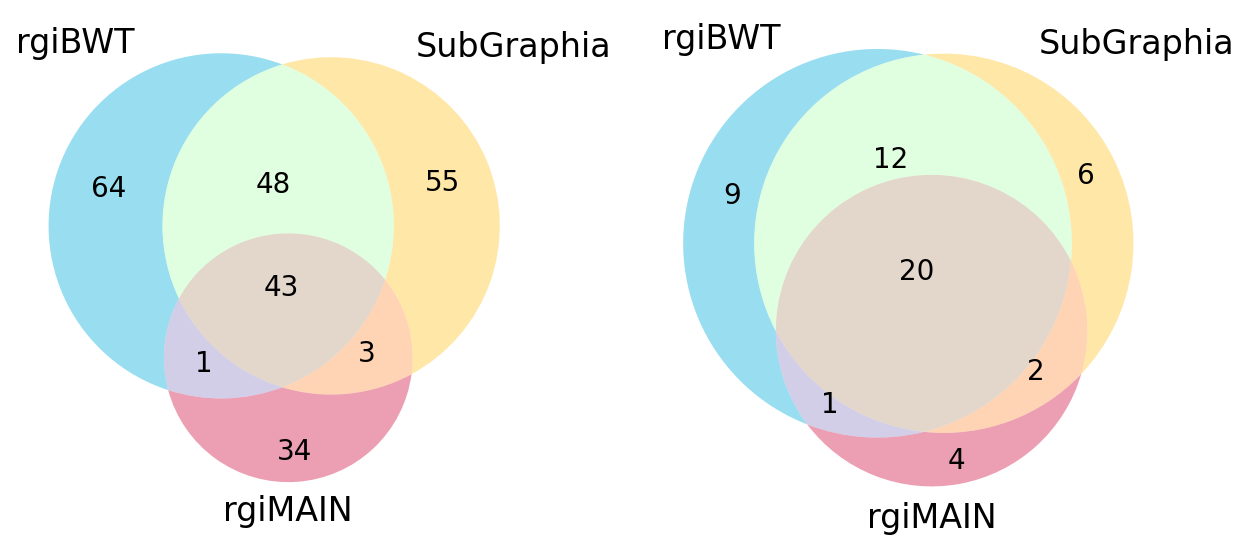

In [3]:
import json
import pandas as pd
from matplotlib_venn import venn3
import matplotlib.pyplot as plt
import seaborn as sns

# load the CARD JSON data, ../filtration_eval_fig3/card.json
with open('/data/raid1_HDD/David/db/CARD_27-01-2026/card.json') as f:
    card_data = json.load(f)

# Read in files

rgiBWT_df = pd.read_csv('rgiBWT_out_ERR14173773.gene_mapping_data.txt', sep='\t')
subgraphia_df = pd.read_csv('../summarized_metadata/ERR14173773_summarized.tsv', sep='\t')
contigs_df = pd.read_csv('scaffolds_rgi_out.txt', sep='\t')

# Split reads_df into two dataframes, reads_df and reads_low_coverage_df
reads_df = rgiBWT_df[rgiBWT_df['Average Percent Coverage'] >= 90.0]
reads_low_coverage_df = rgiBWT_df[rgiBWT_df['Average Percent Coverage'] < 90.0]

# in subgraphia_df, split the 'ARO' column into two columns, 'ARO' and 'instance'
subgraphia_df[['ARO', 'instance']] = subgraphia_df['ARO'].str.split('inst', n=1, expand=True)

# make sure ARO columns in all dataframes are of the same type (string)
reads_df['ARO Accession'] = reads_df['ARO Accession'].astype(str)
subgraphia_df['ARO'] = subgraphia_df['ARO'].astype(str)
contigs_df['ARO'] = contigs_df['ARO'].astype(str)

# create a set of AROs in reads_df, subgraphia_df, and contigs_df
aros_in_reads = set(reads_df['ARO Accession'])
aros_in_subgraphia = set(subgraphia_df['ARO'])
aros_in_contigs = set(contigs_df['ARO'])
all_aros = aros_in_reads.union(aros_in_subgraphia).union(aros_in_contigs)


def find_by_aro(data, target):
    results = []
    if isinstance(data, dict):
        if data.get('ARO_accession') == target:
            results.append(data)
        for v in data.values():
            results.extend(find_by_aro(v, target))
    elif isinstance(data, list):
        for item in data:
            results.extend(find_by_aro(item, target))
    return results

aro_category_dict = {}
for aro in all_aros:
    results = find_by_aro(card_data, aro)
    # get ARO_category from results
    aro_category = results[0]['ARO_category']
    aro_category_keys = results[0]['ARO_category'].keys()
    first_key = list(aro_category_keys)[0]
    # get category_aro_accession from aro_category
    category_aro_accession = aro_category[first_key]['category_aro_accession'] 
    # Add aro and category_aro_accession to a dictionary
    aro_category_dict[aro] = category_aro_accession

# using aro_category_dict, add a new column to reads_df, subgraphia_df, and contigs_df called 'ARO_family' that contains the category_aro_accession for each ARO
reads_df['ARO_family'] = reads_df['ARO Accession'].map(aro_category_dict)
subgraphia_df['ARO_family'] = subgraphia_df['ARO'].map(aro_category_dict)
contigs_df['ARO_family'] = contigs_df['ARO'].map(aro_category_dict)

# create a two panel plot with the left panel showing a Venn diagram of the three sets of AROs in reads_df, subgraphia_df, and contigs_df, and the right panel showing a Venn diagram of the three sets of ARO_family in reads_df, subgraphia_df, and contigs_df
## increase font size of the Venn diagram
plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
venn3([set(reads_df['ARO Accession']), set(subgraphia_df['ARO']), set(contigs_df['ARO'])], 
       ['rgiBWT', 'SubGraphia', 'rgiMAIN'], set_colors=['#00aedb', '#ffc425', '#d11141'], ax=axes[0])
venn3([set(reads_df['ARO_family']), set(subgraphia_df['ARO_family']), set(contigs_df['ARO_family'])], 
       ['rgiBWT', 'SubGraphia', 'rgiMAIN'], set_colors=['#00aedb', '#ffc425', '#d11141'], ax=axes[1])


# save the plot
plt.savefig('../figures_tables/figure_S5.png', dpi=300)